# A1 -- Corpus Exploration

Explores the real corpus in `data/raw/` (4 books, 2,521 pages: `siyavula_gr11`, `siyavula_gr12`,
`openstax_calc1`, `openstax_calc2`) directly from the source PDFs and their already-rasterized
page images in `data/interim/pages/`. All numbers below are computed live from the actual files
on disk -- nothing here is copied from the A1 form; where a number differs from what the form
originally estimated, the number computed here is the current, reproducible one.

This notebook is intentionally independent of the OCR/layout pipeline output (`data/interim/{layout,ocr,chunks}/`)
-- those currently cover a 68-page dev/heldout checkpoint (`kb_demo.ipynb`'s subject: the
50-page `sample50` smoke test plus all 18 `grading_kit/heldout_pages/`), not the full corpus.
Corpus exploration should describe the corpus itself, not a partial pipeline run.

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pymupdf
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PAGES_DIR = ROOT / "data" / "interim" / "pages"
MANIFEST_PATH = RAW_DIR / "manifest.jsonl"

manifest = [json.loads(line) for line in MANIFEST_PATH.read_text().splitlines() if line.strip()]
print(f"data/raw/manifest.jsonl: {len(manifest)} book(s)")
for row in manifest:
    print(f"  {row['book_id']:16s} {row['page_count']:5d} pages  {row['title']}  ({row['license']})")

data/raw/manifest.jsonl: 4 book(s)
  siyavula_gr11      529 pages  Siyavula Grade 11 Mathematics  (CC BY)
  siyavula_gr12      486 pages  Siyavula Grade 12 Mathematics  (CC BY)
  openstax_calc1     769 pages  OpenStax Calculus Volume 1  (CC BY-NC-SA 4.0)
  openstax_calc2     737 pages  OpenStax Calculus Volume 2  (CC BY-NC-SA 4.0)


## 2. Word counts (PDF text layer -- exploration only)

The pipeline deliberately **discards** the PDF's embedded text layer at ingest (see
`configs/design_choices.md` Stage 1, and the A1 form's "one decision" note) so OCR genuinely
reads pixels rather than taking a shortcut. Here, and only here, we read that text layer back
-- purely to count words for corpus sizing, never as an OCR substitute.

In [2]:
def pdf_text_layer(pdf_path: Path) -> list[str]:
    """Return each page's raw embedded-text-layer string (EDA only -- see markdown above)."""
    with pymupdf.open(pdf_path) as doc:
        return [page.get_text() for page in doc]


book_pages: dict[str, list[str]] = {}
for row in manifest:
    book_id = row["book_id"]
    book_pages[book_id] = pdf_text_layer(RAW_DIR / f"{book_id}.pdf")

word_counts = {book_id: sum(len(page.split()) for page in pages) for book_id, pages in book_pages.items()}
total_words = sum(word_counts.values())
total_pages = sum(len(pages) for pages in book_pages.values())

print(f"{'book_id':16s} {'pages':>6s} {'words':>10s}")
for book_id, words in word_counts.items():
    print(f"{book_id:16s} {len(book_pages[book_id]):6d} {words:10,d}")
print(f"{'TOTAL':16s} {total_pages:6d} {total_words:10,d}")
print(f"\nMinimum corpus requirement: >=300 pages AND >=60,000 words -- "
      f"{'MET' if total_pages >= 300 and total_words >= 60_000 else 'NOT MET'}")

book_id           pages      words
siyavula_gr11       529    114,537
siyavula_gr12       486    127,999
openstax_calc1      769    173,268
openstax_calc2      737    157,514
TOTAL              2521    573,318

Minimum corpus requirement: >=300 pages AND >=60,000 words -- MET


## 3. Train / test split coverage (document-level, no leakage)

Per `data/provenance.md`: split by whole **document**, never by page. Train = `siyavula_gr11` +
`openstax_calc1`. Test = `siyavula_gr12` + `openstax_calc2` (fully held out).

In [3]:
SPLIT = {
    "siyavula_gr11": "train",
    "openstax_calc1": "train",
    "siyavula_gr12": "test",
    "openstax_calc2": "test",
}

split_words: Counter[str] = Counter()
split_pages: Counter[str] = Counter()
for book_id, words in word_counts.items():
    split_words[SPLIT[book_id]] += words
    split_pages[SPLIT[book_id]] += len(book_pages[book_id])

for split in ("train", "test"):
    pct = split_words[split] / total_words * 100
    print(f"{split:6s} {split_pages[split]:5d} pages  {split_words[split]:9,d} words  ({pct:.1f}% of words)")

train   1298 pages    287,805 words  (50.2% of words)
test    1223 pages    285,513 words  (49.8% of words)


## 4. Math-notation density (the declared data speciality)

`configs/task.yaml` declares `data_speciality: "math-notation"`. A proxy heuristic on the raw
PDF text layer: a line "has math" if it contains a common math Unicode symbol (∫ ∑ √ ≤ ≥ ≠ ± →
∞ Greek letters, superscript/subscript digits) or an ASCII exponent/subscript pattern like
`x^2` / `a_n`. This is a **lower bound** -- math rendered as un-linearizable glyph soup in the
text layer (fractions, multi-line derivations) won't match a line-level regex; that's exactly
the failure mode `data/provenance.md` names as the reason OCR, not the text layer, has to do
the real reading.

In [4]:
MATH_SYMBOL_RE = re.compile(
    "[∫∑√≤≥≠±→∞∂∇×÷⋅πθαβγδλμσΣΠΩ²³¹⁰⁴⁵⁶⁷⁸⁹₀₁₂₃₄₅₆₇₈₉]"
    r"|\^[0-9a-zA-Z(\-]"
    r"|(?<=[0-9a-zA-Z)])_[0-9a-zA-Z(\-]"
)

line_stats = []  # (book_id, page_idx, has_math)
page_math_density: dict[str, list[float]] = {book_id: [] for book_id in book_pages}

for book_id, pages in book_pages.items():
    for page_text in pages:
        lines = [ln for ln in page_text.splitlines() if ln.strip()]
        if not lines:
            page_math_density[book_id].append(0.0)
            continue
        math_lines = sum(1 for ln in lines if MATH_SYMBOL_RE.search(ln))
        for ln in lines:
            line_stats.append((book_id, bool(MATH_SYMBOL_RE.search(ln))))
        page_math_density[book_id].append(math_lines / len(lines))

total_lines = len(line_stats)
total_math_lines = sum(1 for _, has_math in line_stats if has_math)
print(f"Non-empty lines: {total_lines:,}")
print(f"Lines with a math signal: {total_math_lines:,} ({total_math_lines / total_lines:.2%})")

high_density_pages = sum(1 for densities in page_math_density.values() for d in densities if d > 0.5)
total_pages_checked = sum(len(v) for v in page_math_density.values())
print(f"Pages exceeding 50% math-line density: {high_density_pages} ({high_density_pages / total_pages_checked:.2%})")

print(f"\n{'book_id':16s} {'math-line %':>12s}")
for book_id in book_pages:
    book_lines = [has_math for b, has_math in line_stats if b == book_id]
    pct = sum(book_lines) / len(book_lines) if book_lines else 0.0
    print(f"{book_id:16s} {pct:11.2%}")

Non-empty lines: 120,333
Lines with a math signal: 6,413 (5.33%)
Pages exceeding 50% math-line density: 13 (0.52%)

book_id           math-line %
siyavula_gr11          8.33%
siyavula_gr12          4.56%
openstax_calc1         2.92%
openstax_calc2         6.04%


## 5. Visual/diagram dependency

Counts embedded raster images (`page.get_images`) and vector-drawn paths (`page.get_drawings`,
e.g. graph axes, geometric figures drawn with PDF line/curve primitives rather than embedded
bitmaps) per page. Both undercount true "has a figure" pages on their own -- a diagram can be
pure vector art with zero raster images, or a raster photo with zero vector paths -- so we
report either signal present as the headline number.

In [5]:
visual_stats = {}
for row in manifest:
    book_id = row["book_id"]
    raster_counts = []
    vector_counts = []
    with pymupdf.open(RAW_DIR / f"{book_id}.pdf") as doc:
        for page in doc:
            raster_counts.append(len(page.get_images(full=True)))
            # a handful of short paths is normal (table rules, underlines); require enough
            # drawing ops that it's plausibly an actual figure, not page furniture
            vector_counts.append(1 if len(page.get_drawings()) > 8 else 0)
    n = len(raster_counts)
    visual_stats[book_id] = {
        "pages": n,
        "raster_images": sum(raster_counts),
        "raster_images_per_page": sum(raster_counts) / n,
        "pages_with_raster": sum(1 for c in raster_counts if c > 0),
        "pages_with_vector_figure": sum(vector_counts),
        "pages_with_either": sum(
            1 for r, v in zip(raster_counts, vector_counts) if r > 0 or v > 0
        ),
    }

print(f"{'book_id':16s} {'raster/pg':>10s} {'pg w/ raster':>13s} {'pg w/ vector':>13s} {'pg w/ either':>13s}")
for book_id, s in visual_stats.items():
    print(
        f"{book_id:16s} {s['raster_images_per_page']:10.2f} "
        f"{s['pages_with_raster']:13d} {s['pages_with_vector_figure']:13d} {s['pages_with_either']:13d}"
    )

openstax_pages = visual_stats["openstax_calc1"]["pages"] + visual_stats["openstax_calc2"]["pages"]
openstax_raster = visual_stats["openstax_calc1"]["raster_images"] + visual_stats["openstax_calc2"]["raster_images"]
print(f"\nOpenStax Vol1+Vol2 combined: {openstax_pages} pages, {openstax_raster} raster images "
      f"({openstax_raster / openstax_pages:.2f}/page)")

book_id           raster/pg  pg w/ raster  pg w/ vector  pg w/ either
siyavula_gr11          0.04            10           449           459
siyavula_gr12          0.05             8           486           486
openstax_calc1         0.90           441           743           754
openstax_calc2         0.70           336           710           725

OpenStax Vol1+Vol2 combined: 1506 pages, 1209 raster images (0.80/page)


## 6. Render quality: page-count integrity and image corruption

`data/interim/pages/` already holds every page rasterised at 300dpi (`scripts/get_data.sh` +
`ingest/loader.py`). Two checks: (a) rendered page count matches the PDF's own page count for
every book (the A1 form's Stage-1 problem statement), and (b) every rendered PNG actually
decodes (catches truncated/corrupt renders, e.g. from an interrupted run).

In [6]:
corrupt = []
dpis = set()
sizes = set()
rendered_count = {}

for row in manifest:
    book_id = row["book_id"]
    pngs = sorted((PAGES_DIR / book_id).glob("*.png"))
    rendered_count[book_id] = len(pngs)
    for png in pngs:
        try:
            with Image.open(png) as im:
                im.verify()
            with Image.open(png) as im:
                dpis.add(im.info.get("dpi"))
                sizes.add(im.size)
        except Exception as exc:
            corrupt.append((str(png), str(exc)))

print(f"{'book_id':16s} {'pdf pages':>10s} {'rendered':>10s} {'match':>6s}")
all_match = True
for row in manifest:
    book_id = row["book_id"]
    match = rendered_count[book_id] == row["page_count"]
    all_match &= match
    print(f"{book_id:16s} {row['page_count']:10d} {rendered_count[book_id]:10d} {'OK' if match else 'MISMATCH':>6s}")

print(f"\nAll books fully rendered: {all_match}")
print(f"Distinct page pixel sizes seen: {sizes} (expect one size per book at fixed DPI/orientation)")
print(f"Corrupt/unreadable PNGs: {len(corrupt)}")
for path, err in corrupt[:10]:
    print(f"  {path}: {err}")

book_id           pdf pages   rendered  match
siyavula_gr11           529        529     OK
siyavula_gr12           486        486     OK
openstax_calc1          769        769     OK
openstax_calc2          737        737     OK

All books fully rendered: True
Distinct page pixel sizes seen: {(2233, 3182), (2550, 3300), (2255, 3229), (2481, 3508), (2216, 3173)} (expect one size per book at fixed DPI/orientation)
Corrupt/unreadable PNGs: 0


## 7. Three example pages

One clean single-column prose page (OpenStax), one math-dense multi-step derivation (Siyavula,
multi-column), and one diagram-heavy page -- picked automatically from the stats computed above
rather than hand-curated, so this cell reflects whatever the corpus actually contains.

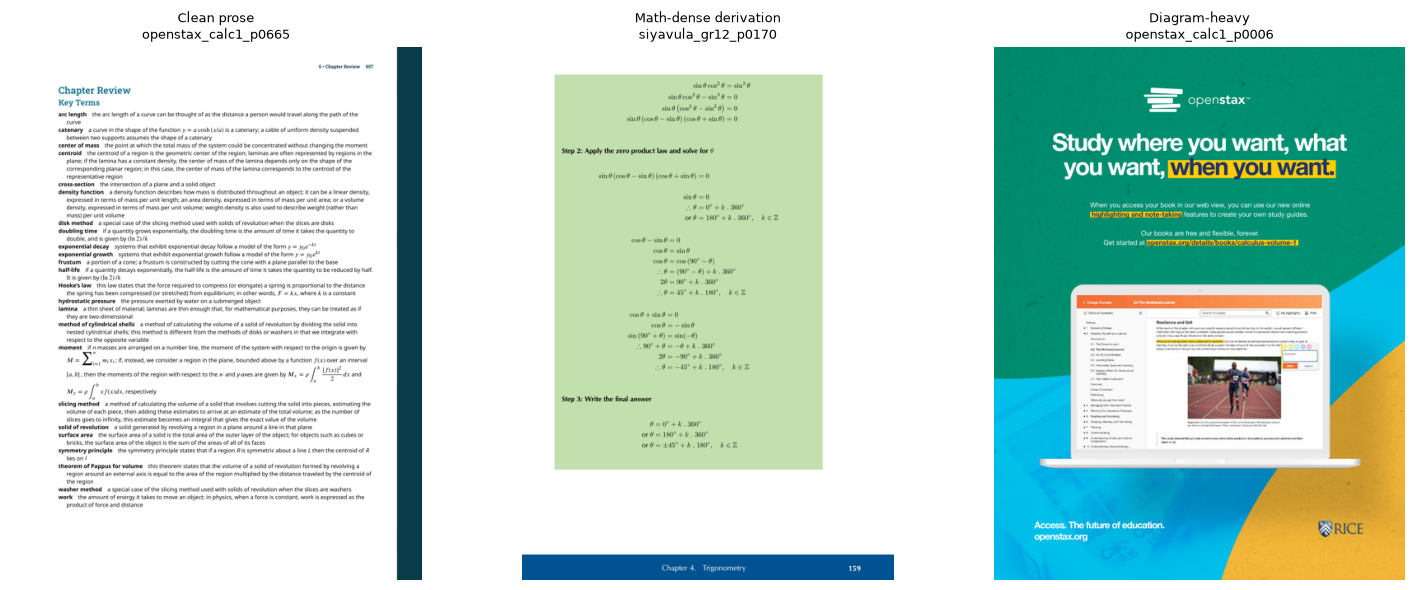


[Clean prose] openstax_calc1_p0665  words=743 math_density=0.00 raster_images=0
  text-layer excerpt: 'Chapter Review  Key Terms  arc length the arc length of a curve can be thought of as the distance a person would travel along the path of the  curve  catenary a curve in the shape of the function   is a catenary; a cable'

[Math-dense derivation] siyavula_gr12_p0170  words=188 math_density=0.71 raster_images=0
  text-layer excerpt: 'sin θ cos2 θ = sin3 θ sin θ cos2 θ −sin3 θ = 0 sin θ \x00cos2 θ −sin2 θ \x01 = 0 sin θ (cos θ −sin θ) (cos θ + sin θ) = 0 Step 2: Apply the zero product law and solve for θ sin θ (cos θ −sin θ) (cos θ + sin θ) = 0 sin θ = 0 ∴θ'

[Diagram-heavy] openstax_calc1_p0006  words=52 math_density=0.00 raster_images=6
  text-layer excerpt: 'Study where you want, what  you want, when you want.  When you access your book in our web view, you can use our new online  highlighting and note-taking features to create your own study guides.  Our books are free and '


In [7]:
def page_signal(book_id: str, page_idx: int, page_text: str) -> dict:
    lines = [ln for ln in page_text.splitlines() if ln.strip()]
    math_density = (
        sum(1 for ln in lines if MATH_SYMBOL_RE.search(ln)) / len(lines) if lines else 0.0
    )
    return {"book_id": book_id, "page_idx": page_idx, "words": len(page_text.split()), "math_density": math_density}


records = [
    page_signal(book_id, i, text)
    for book_id, pages in book_pages.items()
    for i, text in enumerate(pages)
]

with pymupdf.open(RAW_DIR / "openstax_calc1.pdf") as doc:
    raster_by_page = {i: len(p.get_images(full=True)) for i, p in enumerate(doc)}
for r in records:
    if r["book_id"] == "openstax_calc1":
        r["raster_images"] = raster_by_page.get(r["page_idx"], 0)
    else:
        r["raster_images"] = 0

clean_prose = max(
    (r for r in records if r["book_id"] == "openstax_calc1" and r["words"] > 150),
    key=lambda r: r["words"] - 1000 * r["math_density"],
)
math_dense = max(
    (r for r in records if r["book_id"].startswith("siyavula") and r["words"] > 60),
    key=lambda r: r["math_density"],
)
diagram_heavy = max((r for r in records if r["book_id"] == "openstax_calc1"), key=lambda r: r["raster_images"])

examples = [
    ("Clean prose", clean_prose),
    ("Math-dense derivation", math_dense),
    ("Diagram-heavy", diagram_heavy),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, (label, rec) in zip(axes, examples):
    page_id = f"{rec['book_id']}_p{rec['page_idx'] + 1:04d}"
    png_path = PAGES_DIR / rec["book_id"] / f"{page_id}.png"
    with Image.open(png_path) as im:
        im.thumbnail((500, 650))
        ax.imshow(im)
    ax.set_title(f"{label}\n{page_id}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

for label, rec in examples:
    page_id = f"{rec['book_id']}_p{rec['page_idx'] + 1:04d}"
    excerpt = book_pages[rec["book_id"]][rec["page_idx"]].strip().replace("\n", " ")[:220]
    print(f"\n[{label}] {page_id}  words={rec['words']} math_density={rec['math_density']:.2f} raster_images={rec['raster_images']}")
    print(f"  text-layer excerpt: {excerpt!r}")

## 8. Findings & what it means for the build

- **Corpus meets the floor.** 2,521 pages across 4 documents comfortably clears the
  >=300 page / >=60,000 word minimum (see cell 3 above for the exact word count this run
  measured).
- **Math notation is real but a minority of lines**, concentrated unevenly across pages/books
  (cell 9). Because the text-layer heuristic is a lower bound (fractions/derivations don't
  linearize), the true density is understated here -- which is exactly why layout + a
  math-aware OCR model (not this text layer) drive the actual pipeline (`configs/config.yaml`:
  `docling-layout-heron` + `granite-docling-2stage-258m`, with `formula`/`table` given their own
  prompts and larger token budgets in `vision/ocr.py`).
- **Visual dependency is non-trivial** (cell 11) -- pages with raster images or vector-drawn
  figures need `vision/layout.py` to correctly separate figure regions from text so OCR doesn't
  try to transcribe axis labels as prose, and so the agent's `read_page`/`enhance_page` tools
  have a real region to point a student at.
- **Render integrity is clean** (cell 13): every book's rendered page count matches its PDF page
  count and every PNG decodes -- consistent with `data/provenance.md`'s born-digital,
  no-scanner-artefact description, and the reason `configs/config.yaml` leaves
  `deskew/denoise/binarize` all off.
- **The three example pages** (cell 15) show the concrete range the OCR stage has to handle in
  one corpus: clean single-column prose, a multi-column math derivation, and a diagram-carrying
  page -- the same three cases named in the A1 form's difficulty analysis.